In [150]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,PowerTransformer,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error,r2_score,root_mean_squared_error
import joblib as job

In [110]:
car=pd.read_csv("car_sales_data.csv")

In [111]:
car.head()

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101


In [112]:
car.tail()

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
49995,BMW,M5,5.0,Petrol,2018,28664,113006
49996,Toyota,Prius,1.8,Hybrid,2003,105120,9430
49997,Ford,Mondeo,1.6,Diesel,2022,4030,49852
49998,Ford,Focus,1.0,Diesel,2016,26468,23630
49999,VW,Golf,1.4,Diesel,2012,109300,10400


In [113]:
car.duplicated().sum()

np.int64(12)

In [114]:
car.drop_duplicates().reset_index(drop=True)

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101
...,...,...,...,...,...,...,...
49983,BMW,M5,5.0,Petrol,2018,28664,113006
49984,Toyota,Prius,1.8,Hybrid,2003,105120,9430
49985,Ford,Mondeo,1.6,Diesel,2022,4030,49852
49986,Ford,Focus,1.0,Diesel,2016,26468,23630


In [115]:
car.isnull().sum()

Manufacturer           0
Model                  0
Engine size            0
Fuel type              0
Year of manufacture    0
Mileage                0
Price                  0
dtype: int64

In [116]:
print(type(car))

<class 'pandas.core.frame.DataFrame'>


In [117]:
car.head()

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101


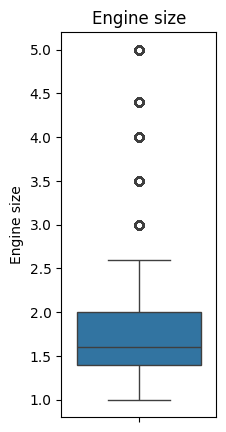

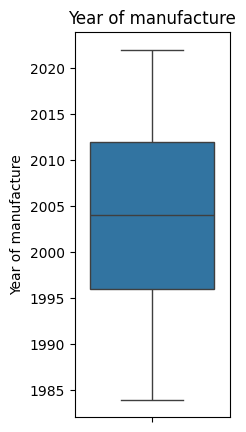

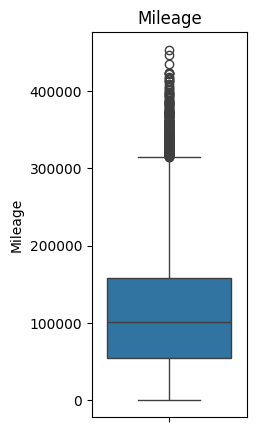

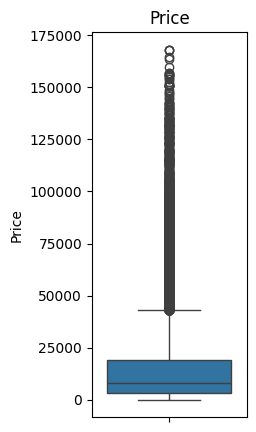

In [118]:
for col in car.select_dtypes(include=["number"]).columns:
    plt.figure(figsize=(2,5))
    sns.boxplot(y=car[col])
    plt.title(col)
    plt.show()
               
               

In [119]:
x=car.drop(columns=["Price"])
y=car["Price"]

In [120]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [121]:
NUMERIC_NUM=x_train.select_dtypes(include=["number"]).columns
CATEGORY_NUM=x_train.select_dtypes(include=["object"]).columns

In [122]:
for col in NUMERIC_NUM:
    Q1=x_train[col].quantile(0.25)
    Q3=x_train[col].quantile(0.75)
    #from the formular
    IQR=Q3-Q1
    LOWER=Q1-IQR*1.5
    UPER=Q3+IQR*1.5
    x_train[col]=x_train[col].clip(LOWER,UPER)
    x_test[col]=x_test[col].clip(LOWER,UPER)

In [123]:
num_pipeline=Pipeline([
    ("skew",PowerTransformer()),
    ("scale",StandardScaler())
])

cat_pipeline=Pipeline([
    ("Enco",OneHotEncoder(handle_unknown="ignore"))
])

In [130]:
preprocessing=ColumnTransformer([
    ("NUMBER",num_pipeline,NUMERIC_NUM),
    ("CATEGORY",cat_pipeline,CATEGORY_NUM)
])

In [132]:
Create_model=Pipeline([
    ("processing",preprocessing),
    ("model",XGBRegressor(
        n_estimetors=300,
        max_depth=4,
        learnig_rate=0.1
    )
    )
])

In [133]:
Create_model.fit(x_train,y_train)

C:\Users\DR SWETU\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:10:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "learnig_rate", "n_estimetors" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,steps,"[('processing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('NUMBER', ...), ('CATEGORY', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [134]:
y_predict=Create_model.predict(x_test)

In [139]:
r2=r2_score(y_test,y_predict)
r2

0.9964727163314819

In [142]:
mae  = mean_absolute_error(y_test,y_predict)
mae

544.8554077148438

In [153]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    Create_model,
    x_train,
    y_train,
    cv=5,
    scoring="r2"
)

print(scores)
print(scores.mean())

C:\Users\DR SWETU\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [04:25:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "learnig_rate", "n_estimetors" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\DR SWETU\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [04:25:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "learnig_rate", "n_estimetors" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\DR SWETU\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [04:25:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "learnig_rate", "n_estimetors" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\DR SWETU\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:2

[0.99576008 0.99652445 0.99649847 0.99667448 0.9966011 ]
0.9964117169380188


In [154]:
train_pred = Create_model.predict(x_train)
test_pred = Create_model.predict(x_test)

from sklearn.metrics import r2_score

print("Train R2:", r2_score(y_train, train_pred))
print("Test R2 :", r2_score(y_test, test_pred))

Train R2: 0.9970225095748901
Test R2 : 0.9964727163314819


In [155]:
print(x_train.columns.tolist())

['Manufacturer', 'Model', 'Engine size', 'Fuel type', 'Year of manufacture', 'Mileage']


In [152]:
job.dump(Create_model,"CAR_SALES.joblib",compress=3)

['CAR_SALES.joblib']